In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
import stim

import os 

while 'honeycomb.py' not in os.listdir():
    os.chdir("..")

from honeycomb import Surface

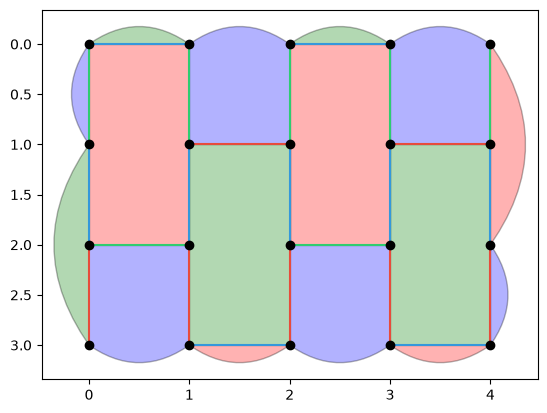

In [14]:
honey = Surface(4, 5)
honey.plot_surface()

In [20]:
circuit = stim.Circuit(honey.initialise_circuit(coordinates='hex'))
# circuit.diagram("detslice-svg")

In [21]:
# TODO do we use letters or words?
COLOUR_MAP = {
    'r' : 'red',
    'g' : 'green',
    'b' : 'blue'
}

def measurement_cycle(honey: Surface, cycle=["rZ", "gX", "bZ", "rX", "gZ", "bX"]):
    """
    measure our stabilizers
    """

    string = ""
    for m in cycle:
        colour = COLOUR_MAP[m[0]]
        flavour = m[1]

        string += f"#{colour}\n"
        string += honey.measure_edges(colour, flavour) + "\n"
        string += "tick\n"
    
    return string

print(measurement_cycle(honey, ['rXX', 'gZZ']))

#red
MX 7 6 8 9 15 10 16 11 12 17 18 13 19 14 
tick
#green
MZ 5 0 1 6 7 2 8 3 9 4 10 11 12 13 
tick



A full cycle looks like:

In [22]:
string = measurement_cycle(honey)
print(string)
c_meas = stim.Circuit(string)
circuit += c_meas

#red
MZ 7 6 8 9 15 10 16 11 12 17 18 13 19 14 
tick
#green
MX 5 0 1 6 7 2 8 3 9 4 10 11 12 13 
tick
#blue
MZ 1 0 2 3 10 5 11 6 12 7 13 8 9 14 16 17 18 19 
tick
#red
MX 7 6 8 9 15 10 16 11 12 17 18 13 19 14 
tick
#green
MZ 5 0 1 6 7 2 8 3 9 4 10 11 12 13 
tick
#blue
MX 1 0 2 3 10 5 11 6 12 7 13 8 9 14 16 17 18 19 
tick



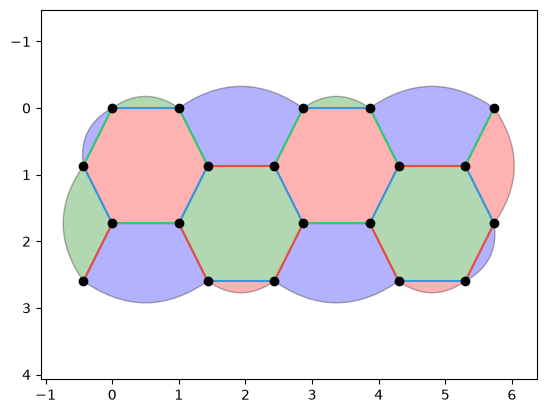

In [25]:
honey.plot_surface(coordinates='hex')

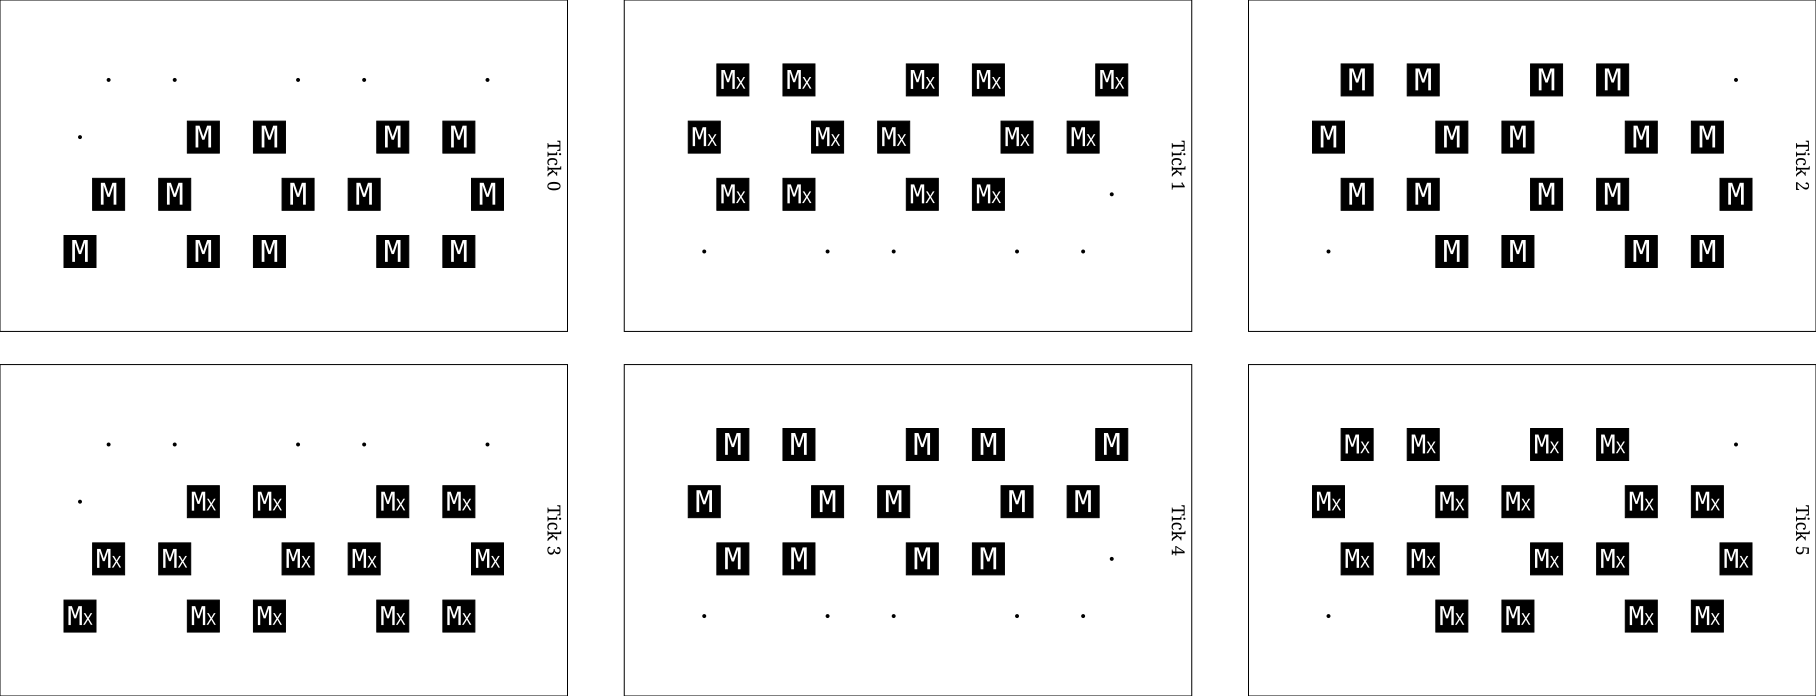

In [26]:
circuit.diagram("detslice-with-ops-svg")